# Battery Data Analysis
Analysis of NASA battery dataset for SOC and SOH prediction

In [14]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.signal import savgol_filter
import sys
import os
# Add the parent directory to the path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
# Now import the modules
from utils.data_loader import load_nasa_battery_data
from utils.plotting import plot_capacity_degradation

## Data Loading

In [24]:
# Load battery data
data_dir = '../data/NASA_batteries_1/'
batteries = load_nasa_battery_data(data_dir)

# Display basic information
print(f"Loaded data for {len(batteries)} batteries")
battery_names = list(batteries.keys())
print(f"Battery IDs: {battery_names}")

# Examine structure of first battery
first_battery = batteries[battery_names[0]]
first_battery['summary'].head()

Found 5 total files in directory
Found 4 battery files: ['B0005.mat', 'B0006.mat', 'B0007.mat', 'B0018.mat']
Processing file ../data/NASA_batteries_1/B0005.mat...
  Processed charge data for cycle 1
  Processed discharge data for cycle 2
  Processed charge data for cycle 3
  Processed discharge data for cycle 20
  Processed charge data for cycle 40
  Processed charge data for cycle 60
  Processed charge data for cycle 80
  Processed charge data for cycle 100
  Processed charge data for cycle 120
  Processed discharge data for cycle 140
  Processed charge data for cycle 160
  Processed charge data for cycle 180
  Processed charge data for cycle 200
  Processed discharge data for cycle 220
  Processed discharge data for cycle 240
  Processed discharge data for cycle 260
  Processed charge data for cycle 280
  Processed charge data for cycle 300
  Processed discharge data for cycle 320
  Processed discharge data for cycle 340
  Processed discharge data for cycle 360
  Processed discharge 

,Cycle,Capacity (Ah),Ambient Temperature (C),Type,SOH
0,1,NaN,24,charge,NaN
1,2,1.856487,24,discharge,1.000000
2,3,NaN,24,charge,NaN
3,4,1.846327,24,discharge,0.994527
4,5,NaN,24,charge,NaN


## Data Preprocessing

In [25]:
def preprocess_battery_data(batteries):
    """Clean and preprocess battery data"""
    processed_data = {}
    
    for battery_id, battery_data in batteries.items():
        # Get summary data
        summary = battery_data['summary'].copy()
        
        # Filter out invalid cycles
        summary = summary[summary['Capacity (Ah)'] > 0]
        
        # Calculate SOH as percentage of initial capacity
        initial_capacity = summary['Capacity (Ah)'].iloc[0]
        summary['SOH'] = summary['Capacity (Ah)'] / initial_capacity
        
        # Add to processed data
        processed_data[battery_id] = {
            'summary': summary,
            'cycles': battery_data['cycles']
        }
    
    return processed_data

# Preprocess data
processed_batteries = preprocess_battery_data(batteries)

## Exploratory Data Analysis

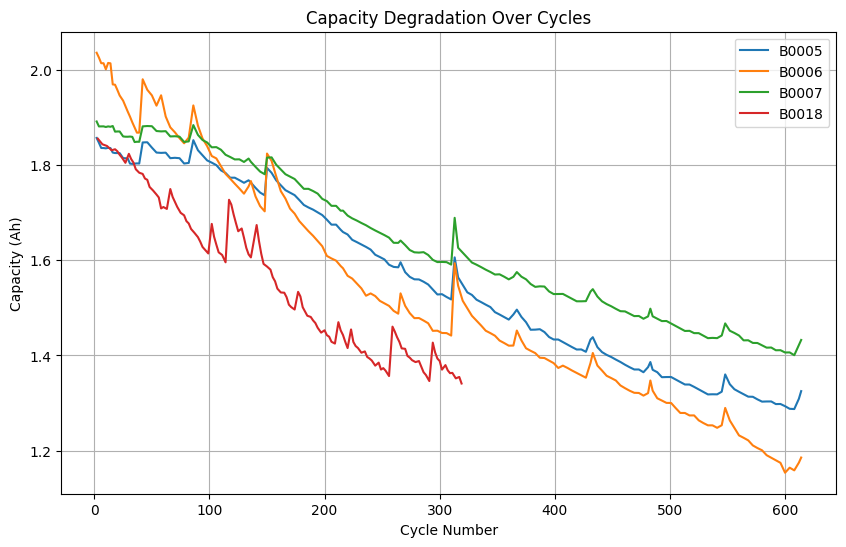

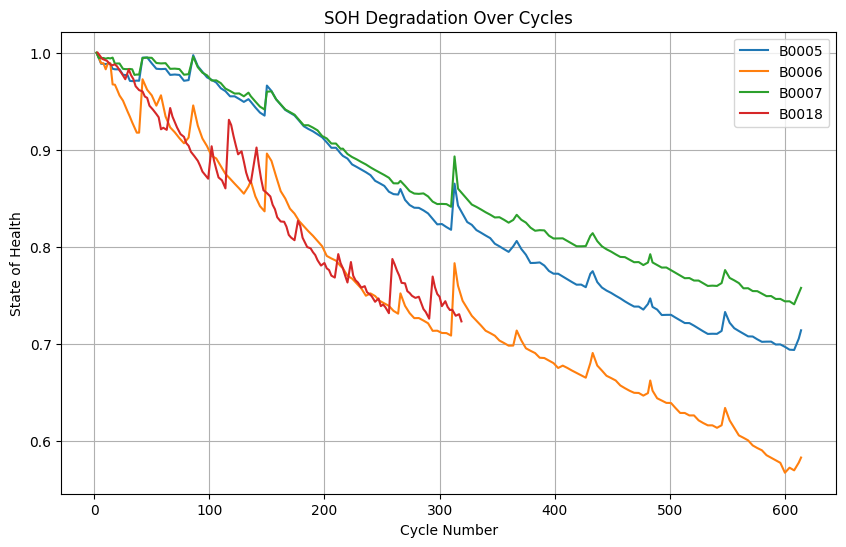

In [26]:
# Plot capacity degradation for all batteries
plt.figure(figsize=(10, 6))
for battery_id, battery_data in processed_batteries.items():
    plt.plot(battery_data['summary']['Cycle'], 
             battery_data['summary']['Capacity (Ah)'], 
             label=battery_id)
    
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('Capacity Degradation Over Cycles')
plt.legend()
plt.grid(True)
plt.show()

# Plot SOH degradation
plt.figure(figsize=(10, 6))
for battery_id, battery_data in processed_batteries.items():
    plt.plot(battery_data['summary']['Cycle'], 
             battery_data['summary']['SOH'], 
             label=battery_id)
    
plt.xlabel('Cycle Number')
plt.ylabel('State of Health')
plt.title('SOH Degradation Over Cycles')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'charge'

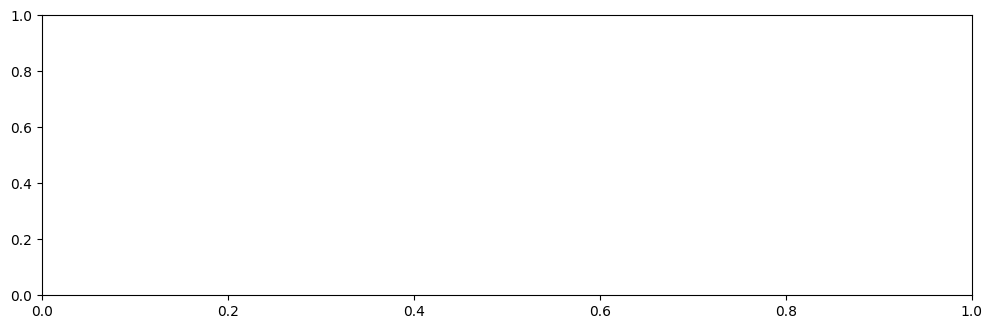

In [27]:
# Analyze voltage and current profiles for a single cycle
battery_id = battery_names[0]
cycle_number = 10  # Choose an early cycle
cycle_data = processed_batteries[battery_id]['cycles'][cycle_number]

plt.figure(figsize=(12, 8))

# Plot charge data
plt.subplot(2, 1, 1)
plt.plot(cycle_data['charge']['Time (s)'], cycle_data['charge']['Voltage (V)'], label='Voltage')
plt.ylabel('Voltage (V)')
plt.title(f'Charge Profile - Battery {battery_id}, Cycle {cycle_number}')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(cycle_data['charge']['Time (s)'], cycle_data['charge']['Current (A)'], label='Current')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot discharge data
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(cycle_data['discharge']['Time (s)'], cycle_data['discharge']['Voltage (V)'], label='Voltage')
plt.ylabel('Voltage (V)')
plt.title(f'Discharge Profile - Battery {battery_id}, Cycle {cycle_number}')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(cycle_data['discharge']['Time (s)'], cycle_data['discharge']['Current (A)'], label='Current')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.grid(True)

plt.tight_layout()
plt.show()

## Feature Engineering

In [28]:
def extract_features(batteries):
    """Extract features from battery cycles"""
    features_list = []
    
    for battery_id, battery_data in batteries.items():
        summary = battery_data['summary']
        cycles = battery_data['cycles']
        
        for idx, row in summary.iterrows():
            cycle_num = int(row['Cycle'])
            
            if cycle_num not in cycles:
                continue
            
            cycle_data = cycles[cycle_num]
            
            # Skip cycles with missing data
            if 'charge' not in cycle_data or 'discharge' not in cycle_data:
                continue
                
            charge = cycle_data['charge']
            discharge = cycle_data['discharge']
            
            # Calculate features
            features = {
                'battery_id': battery_id,
                'cycle': cycle_num,
                'capacity': row['Capacity (Ah)'],
                'soh': row['SOH'],
                
                # Charge features
                'charge_time': charge['Time (s)'].max(),
                'charge_voltage_mean': charge['Voltage (V)'].mean(),
                'charge_voltage_max': charge['Voltage (V)'].max(),
                'charge_current_mean': charge['Current (A)'].mean(),
                
                # Discharge features
                'discharge_time': discharge['Time (s)'].max(),
                'discharge_voltage_mean': discharge['Voltage (V)'].mean(),
                'discharge_voltage_min': discharge['Voltage (V)'].min(),
                'discharge_current_mean': abs(discharge['Current (A)'].mean()),
                
                # Temperature features (if available)
                'charge_temp_mean': charge['Temperature (C)'].mean() if 'Temperature (C)' in charge else np.nan,
                'discharge_temp_mean': discharge['Temperature (C)'].mean() if 'Temperature (C)' in discharge else np.nan,
                
                # Energy features
                'charge_energy': np.trapz(charge['Voltage (V)'] * charge['Current (A)'], charge['Time (s)']),
                'discharge_energy': abs(np.trapz(discharge['Voltage (V)'] * discharge['Current (A)'], discharge['Time (s)']))
            }
            
            features_list.append(features)
    
    # Create DataFrame
    features_df = pd.DataFrame(features_list)
    
    # Calculate efficiency
    features_df['energy_efficiency'] = features_df['discharge_energy'] / features_df['charge_energy']
    
    return features_df

# Extract features
features_df = extract_features(processed_batteries)

KeyError: 'discharge_energy'

In [ ]:
# Check feature correlation with SOH
plt.figure(figsize=(12, 10))
numeric_features = features_df.select_dtypes(include=['float64', 'int64']).drop(['soh', 'capacity'], axis=1)
correlation = numeric_features.corrwith(features_df['soh']).sort_values(ascending=False)

sns.barplot(x=correlation.values, y=correlation.index)
plt.title('Feature Correlation with State of Health')
plt.xlabel('Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Selection and Data Preparation

In [ ]:
# Select relevant features based on correlation
important_features = correlation[abs(correlation) > 0.5].index.tolist()
print("Selected features:", important_features)

# Create data for LSTM (time-series approach)
def prepare_lstm_data(features_df, sequence_length=10):
    """Prepare sequence data for LSTM"""
    lstm_data = {}
    
    for battery_id in features_df['battery_id'].unique():
        battery_features = features_df[features_df['battery_id'] == battery_id].sort_values('cycle')
        
        # Create sequences
        X_sequences = []
        y_soh = []
        
        for i in range(len(battery_features) - sequence_length):
            # Input sequence: features from i to i+sequence_length
            sequence = battery_features.iloc[i:i+sequence_length][important_features].values
            X_sequences.append(sequence)
            
            # Target: SOH at i+sequence_length
            target_soh = battery_features.iloc[i+sequence_length]['soh']
            y_soh.append(target_soh)
        
        if X_sequences:  # Check if we have sequences
            lstm_data[battery_id] = {
                'X': np.array(X_sequences),
                'y': np.array(y_soh)
            }
    
    return lstm_data

# Prepare LSTM data
lstm_data = prepare_lstm_data(features_df)

# Prepare data for XGBoost (tabular approach)
X_xgboost = features_df[important_features]
y_xgboost_soh = features_df['soh']
y_xgboost_capacity = features_df['capacity']

# Save processed data for model training
import pickle
os.makedirs('../models', exist_ok=True)

with open('../models/lstm_data.pkl', 'wb') as f:
    pickle.dump(lstm_data, f)
    
with open('../models/xgboost_data.pkl', 'wb') as f:
    pickle.dump({
        'X': X_xgboost,
        'y_soh': y_xgboost_soh,
        'y_capacity': y_xgboost_capacity,
        'features': important_features,
        'metadata': features_df[['battery_id', 'cycle']]
    }, f)

print("Data processing complete. Files saved to ../models/")